In [303]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🧹 Étape 2 : Préparation & Nettoyage de Données (Data Wrangling)

Cette étape correspond au deuxième chapitre du projet. L'objectif est d'effectuer un audit de qualité de nos données brutes, puis de mettre en œuvre un nettoyage rigoureux de celles-ci. On constatera que nos données sont synthétiques et ne sont pas très réalistes, donc on commencera par mettre un peu de chaos là-dedans pour les rendre plus naturelles.

### 1. Initialisation et imports

In [304]:
import os
import sys
import pandas as pd
import numpy as np
import datetime
import random as rd

print("Librairies prêtes pour le Wrangling !")

Librairies prêtes pour le Wrangling !


### 2. Chargement du dataset brut et Audit Initial

On charge les données brutes, on perturbe ses valeurs numériques arbitrairement pour les raisons évoquées plus haut, puis on inspecte la qualité du dataset (taux de valeurs manquantes, présence de doublons, types erronés). On peut faire plusieurs constats :
- Les dates et les heures sont toutes au format string, ce qu'on devra corriger pour les rendre exploitables.
- Il y a des valeurs manquantes, mais qui suivent des patterns réguliers. Par exemple, dans la colonne "Reason for Cancelling by Customer", on a des valeurs manquantes partout où la course n'est pas annulée par le client.
- L'indexation des enregistrements est totalement aléatoire ; on les triera par dates pour faciliter leur utilisation.
- On a plusieurs colonnes qui n'auront aucune utilité dans notre projet (par exemple l'ID de la course) ; on les supprimera.
- On n'a pas de lignes entièrement dupliquées, mais certaines ID de course qui le sont ; on attribuera ça au fait que les données sont synthétiques et les ID générées aléatoirement, vraisemblablement sans souci d'exclusivité, donc on les ignorera – puisque l'on ignorera l'ID d'une manière générale. Si cela était survenu avec des données réelles, on envisagerait de supprimer ces enregistrements, qui sont assez peu nombreux par rapport à la taille de notre dataset.

In [305]:
main_data_path = '../data/raw/ncr_ride_bookings.csv'
df = pd.read_csv(main_data_path)

In [306]:
# On massacre les données synthétiques pour que ça ressemble un peu plus à quelque chose

valeurs_nulles = df["Booking Value"].notna().astype(float) # On enregistre la position des valeurs nulles pour les retranscrire

df["Ride Distance"] = [np.exp(-rd.random())*50 + 10 for _ in range(len(df))]
df["Ride Distance"] = df["Ride Distance"].map(lambda x : abs(x + rd.gauss()*5))
df["Ride Distance"] = df["Ride Distance"]*valeurs_nulles

df["Avg CTAT"] = df["Ride Distance"].map(lambda x : abs(x/3 + rd.gauss()*15)) + 10
df["Avg CTAT"] = df["Avg CTAT"].map(lambda x : abs(x + rd.gauss()*5))
df["Avg CTAT"] = df["Avg CTAT"]*valeurs_nulles

df["Avg VTAT"] = [np.exp(-rd.random())*15 + 1/(rd.random()+1e-2) for _ in range(len(df))]
df["Avg VTAT"] = df["Avg VTAT"].map(lambda x : abs(x + rd.gauss()*5))
df["Avg VTAT"] = df["Avg VTAT"]*valeurs_nulles

df["Booking Value"] = df["Ride Distance"] * (df["Avg VTAT"]/3 + df["Avg CTAT"]) / 2 # On crée une corrélation avec la distance et le temps d'attente
df["Booking Value"] = df["Booking Value"].map(lambda x : abs(x + rd.gauss()*10)) + 50
mois = df["Date"].map(lambda x : x[5:7]).astype(float) # On crée une corrélation avec le mois pour légèrement augmenter les prix en été
df["Booking Value"] = df["Booking Value"] * 3*np.exp(-(mois/6 - 1.25)**2 + 1)/5
df["Booking Value"] = df["Booking Value"]*valeurs_nulles

In [307]:
# On effectue un audit rapide avec .info(), .isnull().sum() et .duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           150000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [308]:
# Vérification de la présence de valeurs nulles
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                                  0
Avg CTAT                                  0
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                             0
Ride Distance                             0
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [309]:
# Vérification de l'absence de lignes dupliquées
df.duplicated().sum()

np.int64(0)

In [310]:
# Vérification de l'absence de courses dupliquées : on constate qu'on en a
# Étant donné que ce sont des données générées par IA, nous n'allons pas prendre ça en compte
df["Booking ID"].duplicated().sum()

np.int64(1233)

### 3. Uniformisation des Formats de Dates

On uniformise les deux colonnes temporelles (Date et Time) pour les convertir en une seule colonne au format datetime via la fonction pd.to_datetime (à noter que dans notre contexte, comme nous devons recharger le CSV à chaque notebook, on perdra cette transformation et on devra la refaire). Avant quoi on aura fait une étude de Regex pour s'assurer que toutes les dates et heures sont données sur le même format (YYYY-MM-DD pour la date et HH:MM:SS pour l'heure). On triera ensuite les données par date par commodité d'utilisation.

In [311]:
# On fait un Regex pour voir si un Date et l'heure est incorecte ou mauvais format 
import re
pattern_time = re.compile("[0-9][0-9]:[0-9][0-9]:[0-9][0-9]")
pattern_date = re.compile("[0-9][0-9][0-9][0-9]-[0-9][0-9]-[0-9][0-9]")
dummy_time = df["Time"].map(lambda x : True if pattern_time.match(x) else False)
print("Time :", dummy_time.sum())
dummy_date = df["Date"].map(lambda x : True if pattern_date.match(x) else False)
print("Date :", dummy_date.sum())

Time : 150000
Date : 150000


In [312]:
# On crée une colonne avec la Date et l'heure au format DateTime
df["Date"] = pd.to_datetime(df["Date"] + ' ' + df["Time"])
df = df.drop("Time", axis=1)
df["Date"]

0        2024-03-23 12:29:38
1        2024-11-29 18:01:39
2        2024-08-23 08:56:10
3        2024-10-21 17:17:25
4        2024-09-16 22:08:00
                 ...        
149995   2024-11-11 19:34:01
149996   2024-11-24 15:55:09
149997   2024-09-18 10:55:15
149998   2024-10-05 07:53:34
149999   2024-03-10 15:38:03
Name: Date, Length: 150000, dtype: datetime64[ns]

In [313]:
# On trie les données par date
df = df.sort_values(by="Date")

### 4. Identification et Filtrage des Valeurs Aberrantes (Outliers)

On cherche à détecter la présence d'outliers sur les colonnes avec des valeurs numériques. On commence par utiliser la fonction describe() pour se faire une idée "à l'œil" de celles-ci.

In [314]:
# On se fait un aperçu des données, notamment pour chercher la présence d'outliers
df.describe()

,Date,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000,150000.000000,150000.000000,10500.0,27000.0,9000.0,150000.000000,150000.000000,93000.000000,93000.000000
mean,2024-07-01 07:14:41.251033600,9.655084,18.320726,1.0,1.0,1.0,589.426500,28.250391,4.230992,4.404584
min,2024-01-01 00:19:34,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000,3.000000,3.000000
25%,2024-03-31 22:55:36.249999872,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000,4.100000,4.200000
50%,2024-07-01 09:24:52.500000,8.695344,17.671802,1.0,1.0,1.0,498.519855,33.961385,4.300000,4.500000
75%,2024-09-30 13:46:07.249999872,14.986856,30.133560,1.0,1.0,1.0,921.927285,44.883307,4.600000,4.800000
max,2024-12-30 23:36:11,123.192593,96.126316,1.0,1.0,1.0,5451.396529,79.060608,5.000000,5.000000
std,NaN,10.784205,16.473676,0.0,0.0,0.0,590.612943,21.172459,0.436871,0.437819


La colonne "Booking Value" est la seule à posséder des outliers potentielles (le max est très au-dessus du troisième quartile), donc on vérifie l'histogramme de cette grandeur pour s'assurer que ces valeurs semblent cohérentes avec la distribution générale. C'est le cas, donc on ne s'en' préoccupe pas. (Note : c'est une étude que nous avions faite initialement avec les données synthétiques non-modifiées, qui donnait un résultat similaire ; ici, c'est bien sûr une conséquence de la façon dont nous les avons régénérées.)

(array([4.8012e+04, 2.7500e+02, 1.0140e+03, 2.1580e+03, 3.2350e+03,
        4.0670e+03, 4.6980e+03, 5.1460e+03, 5.5160e+03, 5.5420e+03,
        5.4560e+03, 5.2520e+03, 5.1140e+03, 4.7320e+03, 4.4450e+03,
        4.3100e+03, 3.8340e+03, 3.5870e+03, 3.2460e+03, 2.9570e+03,
        2.6710e+03, 2.5240e+03, 2.2970e+03, 2.0270e+03, 1.9440e+03,
        1.7510e+03, 1.5310e+03, 1.3380e+03, 1.2420e+03, 1.0960e+03,
        1.0200e+03, 8.9400e+02, 8.3700e+02, 7.4900e+02, 6.2300e+02,
        5.3400e+02, 5.4200e+02, 4.5000e+02, 3.9800e+02, 3.7200e+02,
        3.2000e+02, 2.6500e+02, 2.6200e+02, 2.1200e+02, 1.9700e+02,
        1.3800e+02, 1.6400e+02, 1.4500e+02, 1.1100e+02, 1.1100e+02,
        8.0000e+01, 7.8000e+01, 7.2000e+01, 6.0000e+01, 4.5000e+01,
        5.0000e+01, 3.4000e+01, 2.9000e+01, 2.9000e+01, 2.0000e+01,
        1.5000e+01, 2.1000e+01, 1.5000e+01, 1.7000e+01, 9.0000e+00,
        1.3000e+01, 7.0000e+00, 1.0000e+01, 5.0000e+00, 1.0000e+01,
        2.0000e+00, 3.0000e+00, 1.0000e+00, 3.00

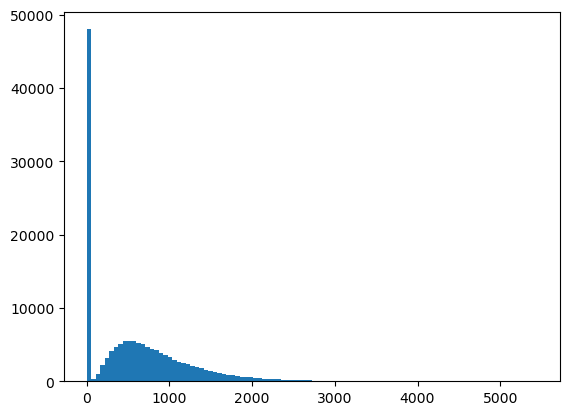

In [315]:
import matplotlib.pyplot as plt
plt.hist(df["Booking Value"], bins=100)

### 5. Sauvegarde des données propres

On enregistre nos données nettoyées dans le répertoire `data/processed/`.

In [316]:
# Aperçu du dataset final :
df

,Date,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
122017,2024-01-01 00:19:34,"""CNR4352144""",Completed,"""CID8362794""",Bike,Udyog Vihar,Ambience Mall,0.007125,28.343157,NaN,NaN,NaN,NaN,NaN,NaN,419.656808,54.403511,4.8,4.8,Cash
79457,2024-01-01 01:35:18,"""CNR9147645""",Completed,"""CID8300238""",Go Mini,Basai Dhankot,Madipur,8.051596,21.722728,NaN,NaN,NaN,NaN,NaN,NaN,272.677149,40.481723,4.2,4.1,Uber Wallet
19130,2024-01-01 01:37:50,"""CNR1009222""",Cancelled by Driver,"""CID2030746""",Go Sedan,Tughlakabad,Greater Kailash,0.000000,0.000000,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
47361,2024-01-01 01:48:03,"""CNR2740479""",Cancelled by Driver,"""CID3231181""",Auto,Palam Vihar,Kherki Daula Toll,0.000000,0.000000,NaN,NaN,1.0,Personal & Car related issues,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
33452,2024-01-01 01:49:56,"""CNR7650148""",Cancelled by Driver,"""CID3381661""",Go Sedan,Narsinghpur,Pulbangash,0.000000,0.000000,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37673,2024-12-30 22:58:00,"""CNR9030698""",Completed,"""CID6939658""",Bike,DLF Phase 3,Okhla,14.969327,11.071073,NaN,NaN,NaN,NaN,NaN,NaN,476.640730,60.222935,4.4,4.8,UPI
61365,2024-12-30 23:03:14,"""CNR1507833""",Completed,"""CID9905090""",eBike,Saket,Noida Sector 62,12.493995,34.215069,NaN,NaN,NaN,NaN,NaN,NaN,775.914923,40.883461,3.8,4.3,UPI
2518,2024-12-30 23:17:05,"""CNR2265113""",Completed,"""CID4170406""",Go Mini,GTB Nagar,Anand Vihar ISBT,2.113810,55.446784,NaN,NaN,NaN,NaN,NaN,NaN,689.833540,24.913603,4.3,4.6,UPI
88884,2024-12-30 23:21:12,"""CNR4066733""",Completed,"""CID8938559""",Uber XL,Ashram,Vasant Kunj,5.638634,29.682250,NaN,NaN,NaN,NaN,NaN,NaN,799.738284,50.490099,5.0,4.3,Uber Wallet


In [317]:
processed_path = '../data/processed/cleaned_data_sample.csv'
# Sauvegarde avec df.to_csv()
df.to_csv(processed_path, index=False)
print(f"💾 Données propres sauvegardées dans : {processed_path}")

💾 Données propres sauvegardées dans : ../data/processed/cleaned_data_sample.csv
